In [1]:
import sys
import os

sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models')

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a depende

In [2]:
X1 = pd.read_csv("mod_data/X1.1", index_col="QSPRID")
X2 = pd.read_csv("mod_data/X2.1", index_col="QSPRID")
X3 = pd.read_csv("mod_data/X3.1", index_col="QSPRID")
y1 = pd.read_csv("mod_data/y1.1", index_col="QSPRID")
y2 = pd.read_csv("mod_data/y2.1", index_col="QSPRID")
y3 = pd.read_csv("mod_data/y3.1", index_col="QSPRID")


In [3]:
X1

,300,301,302,303,304,305,306,307,308,309,...,RDkit_fr_priamide,RDkit_fr_pyridine,RDkit_fr_sulfide,RDkit_fr_sulfonamd,RDkit_fr_sulfone,RDkit_fr_thiazole,RDkit_fr_thiophene,RDkit_fr_unbrch_alkane,RDkit_fr_urea,RDkit_qed
QSPRID,,,,,,,,,,,,,,,,,,,,,
A2ARDataset_0000,-0.308563,0.516990,0.283642,0.266294,-0.247365,-1.128524,0.309840,-0.524603,-0.147377,-0.032262,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.719563
A2ARDataset_0001,-0.155300,0.636047,0.227501,0.038977,0.000860,-0.772830,0.972226,0.031980,0.480479,0.239048,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.173447
A2ARDataset_0002,-0.723099,0.587804,0.056007,0.356455,-0.079368,-0.746009,0.682991,-0.369075,-0.278554,-0.152143,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.897659
A2ARDataset_0003,-0.129878,0.716170,0.359885,-0.407336,-0.058970,-1.122444,0.639601,-0.035885,0.156267,0.133295,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.281880
A2ARDataset_0004,-0.366854,0.472275,0.327102,0.380823,-0.178509,-1.128237,0.387270,-0.324224,-0.027483,-0.075962,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.705221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2ARDataset_2402,-0.320582,0.624884,0.077183,0.139234,0.043471,-0.632272,0.603211,0.004710,0.099075,0.059412,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.418088
A2ARDataset_2403,-0.782738,0.409371,0.360127,-0.001428,0.037057,-0.815762,0.657149,0.014185,0.876741,0.191767,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.375281
A2ARDataset_2404,-0.126299,0.349761,0.088746,-0.017066,0.356339,-0.644341,0.443447,-0.405881,0.233072,0.084093,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.530334


In [4]:
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [5]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=1, random_state=42)
X1, y1 = smote.fit_resample(X1, y1)
display(pd.DataFrame(X1))

,0,1,2,3,4,5,6,7,8,9,...,3066,3067,3068,3069,3070,3071,3072,3073,3074,3075
0,0.629350,0.409822,0.114763,0.849649,-1.302256,-1.582738,-0.678928,-1.233195,-1.434335,-1.134524,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,1.233341
1,1.225274,0.942670,-0.168389,-0.169440,-0.341978,-0.052202,2.212653,0.803415,0.814574,0.266891,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,4.974340,-0.279983,-1.882446
2,-0.982475,0.726753,-1.033329,1.253848,-0.652347,0.063208,0.950025,-0.664100,-1.904197,-1.753757,...,-0.081803,2.465924,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,2.249445
3,1.324123,1.301264,0.499300,-2.170308,-0.573437,-1.556576,0.760613,0.555091,-0.346715,-0.279360,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,2.389444,-0.279983,-1.263797
4,0.402699,0.209699,0.333955,1.363094,-1.035884,-1.581501,-0.340915,-0.499982,-1.004890,-1.360252,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,1.151519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4629,1.032254,0.229924,0.599687,-2.032301,-0.221510,-0.969474,0.562910,0.238983,-1.371945,-0.892411,...,-0.081803,1.057649,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,-1.090632
4630,0.852744,2.780378,-0.303757,0.045130,-0.705685,0.354237,2.359929,0.399819,-0.237312,-0.480343,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,-0.886180
4631,1.077851,0.406309,0.009425,-2.073997,-0.936921,-0.010000,0.142849,-0.608348,-0.839790,-0.252830,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,0.321485
4632,0.728076,1.615808,0.402721,-0.872904,-0.449266,0.046455,1.877900,0.718067,-0.754062,-0.452396,...,-0.081803,1.411798,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,-1.019934


In [6]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit_transform(X1)
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Např. najít počet komponent, které vysvětlí 95 % rozptylu
n_components = np.argmax(cum_var >= 0.95) + 1

In [7]:
from sklearn.decomposition import PCA
pca = PCA(n_components=n_components)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

In [8]:
n_components

741

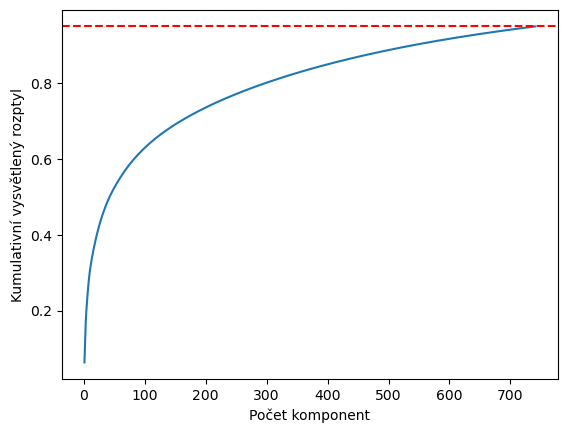

In [9]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [10]:

# Přidejte cestu k vašemu lokálnímu repozitáři
import sys
import os

# Přidání cesty k lokálnímu repozitáři na začátek sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Zkontrolujte, zda je cesta v sys.path
print(sys.path)

from importlib import reload

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected
# Znovu načtěte modul, abyste zajistili, že je správně importován
reload(sys.modules['qsprpred.extra.gpu.models.neural_network'])

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected

os.chdir('/home/ubuntu/Bakalarka/QSPRpred')
print(os.getcwd())


import sys
import importlib.util

# Přidání cesty k repozitáři do sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Specifikujte cestu k souboru, který chcete importovat
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/neural_network.py'
module_name = 'qsprpred.extra.gpu.models.neural_network'

# Načtěte modul z konkrétní cesty
spec = importlib.util.spec_from_file_location(module_name, module_path)
neural_network = importlib.util.module_from_spec(spec)
spec.loader.exec_module(neural_network)

# Nyní můžete používat třídu STFullyConnected
STFullyConnected = neural_network.STFullyConnected

['/home/ubuntu/Bakalarka/QSPRpred', '/Applications/DataSpell.app/Contents/plugins/python-ce/helpers-pro/jupyter_debug', '/Applications/DataSpell.app/Contents/plugins/python-ce/helpers/pydev', '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python311.zip', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/lib-dynload', '', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages']
/home/ubuntu/Bakalarka/QSPRpred
lol


In [13]:
import optuna
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix, matthews_corrcoef, f1_score, accuracy_score

def objective(trial, X_train, y_train, X_val, y_val):
    """Definice cílové funkce pro Optunu"""

    # Návrh hyperparametrů pro dopřednou neuronovou síť
    params = {
        'dropout_frac': trial.suggest_float("dropout_frac", 0, 0.9),
        'patience': trial.suggest_int("patience", 10, 200),
        'tol': trial.suggest_float("tol", 1e-5, 1e-2, log=True),
        'weight_decay': trial.suggest_float("weight_decay", 1e-6, 1e-1, log=True),
        'n_epochs': trial.suggest_int("n_epochs", 200, 2000),
        'batch_size': trial.suggest_categorical("batch_size", [64, 128, 256, 512, 1024]),
        'optimizer': trial.suggest_categorical("optimizer", ["AdamW", "RMSprop"]),
        'lr': trial.suggest_categorical("lr", [1, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]),
        'neuron_layers': trial.suggest_categorical("neuron_layers_size", ["[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]", "[2048, 1024, 512, 256, 128, 64, 32, 16, 8]", "[4096, 1024, 256, 64, 8]", "[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]", "[4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096]", "[200]", "[2000]", "[2000, 1000]", "[2000, 1000, 500]", "[1000, 50]", "[4000, 2000]", "[4000, 2000, 1000, 500]", "[4000, 2000, 2000, 500]"])
    }

    neuron_layers_dict = {
        "[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]": [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8],
        "[2048, 1024, 512, 256, 128, 64, 32, 16, 8]": [2048, 1024, 512, 256, 128, 64, 32, 16, 8],
        "[4096, 1024, 256, 64, 8]": [4096, 1024, 256, 64, 8],
        "[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]": [4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8],
        "[4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096]": [4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096],
        "[200]": [200],
        "[2000]": [2000],
        "[2000, 1000]": [2000, 1000],
        "[2000, 1000, 500]": [2000, 1000, 500],
        "[1000, 50]": [1000, 50],
        "[4000, 2000]": [4000, 2000],
        "[4000, 2000, 1000, 500]": [4000, 2000, 1000, 500],
        "[4000, 2000, 2000, 500]": [4000, 2000, 2000, 500]
    }
    params['neuron_layers'] = neuron_layers_dict[params['neuron_layers']]
    opt_func = optim.AdamW if params['optimizer'] == "AdamW" else optim.RMSprop

    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Model
    model = STFullyConnected(
        n_dim=X_train.shape[1],
        n_class=1,
        device=device,
        act_fun=F.selu,
        dropout_frac=params['dropout_frac'],
        patience=params['patience'],
        tol=params['tol'],  # Opraveno: nyní používáme hodnotu z trial
        weight_decay=params['weight_decay'],
        n_epochs=params['n_epochs'],
        neuron_layers=params['neuron_layers'],  # Použití neuron_layers_size
        batch_size=params['batch_size'],
        optimizer=opt_func,
        lr=params['lr'],
    )
    # Trénink a predikce
    model.fit(X_train, y_train, X_val, y_val)
    preds = model.predict(X_val)
    preds_bin = preds > 0.5

    # Metiky
    f1 = f1_score(y_val, preds_bin)
    acc = accuracy_score(y_val, preds_bin)
    mcc = matthews_corrcoef(y_val, preds_bin)

    # Můžeš logovat i do trialu
    trial.set_user_attr("f1", f1)
    trial.set_user_attr("acc", acc)
    display(confusion_matrix(y_val, preds_bin))
    return mcc  # maximalizujeme MCC


In [ ]:
study = optuna.create_study(
    study_name="A2AR_nn",  # jméno pro pozdější načtení
    direction="maximize",
    sampler=optuna.samplers.NSGAIISampler(),
    storage="sqlite:///optuna_results.db",
    load_if_exists=True  # pokud už existuje, nepřepíše ji
)

# Spusť optimalizaci
study.optimize(
    lambda trial: objective(trial, X1, y1, X2, y2),
    n_trials=1000
)
print("Best MCC:", study.best_value)
print("Best parameters:", study.best_params)

# Pokud chceš F1 a ACC u nejlepšího modelu:
print("Best F1:", study.best_trial.user_attrs["f1"])
print("Best ACC:", study.best_trial.user_attrs["acc"])

[I 2025-05-20 18:55:44,141] Using an existing study with name 'A2AR_nn' instead of creating a new one.


42


In [ ]:

model = STFullyConnected(
        n_dim=X1.shape[1],
        n_class=1,
        device="cuda",
        act_fun=F.selu,
        dropout_frac=0.7587301567075606,
        patience=0.00010905325401069917,
        tol=0,  # Opraveno: nyní používáme hodnotu z trial
        weight_decay=0.024542235145206714,
        n_epochs=403,
        neuron_layers= [200],  # Použití neuron_layers_size
        batch_size=128,
        optimizer=optim.AdamW,
        lr=1e-06,
    print_outputs= 2
    )
model.fit(X1,y1,X2,y2) #0.6084853456048988

In [ ]:
preds = model.predict(X2)
preds_bin = preds > 0.5

mcc = matthews_corrcoef(y2, preds_bin)
display(mcc)

In [ ]:
preds = model.predict(X3)
preds_bin = preds > 0.5

    # Metiky
f1 = f1_score(y3, preds_bin)
acc = accuracy_score(y3, preds_bin)
mcc = matthews_corrcoef(y3, preds_bin)

In [ ]:
display(mcc) # 0.17324800323685596

In [ ]:
study_4.best_params